<a href="https://colab.research.google.com/github/chocozaa/Project-Machine-Learning/blob/main/Project_Machine_Learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## **Perbandingan Algoritma Machine Learning dalam Klasifikasi Jenis Wine Berdasarkan Karakteristik Kimia**

# **LATAR BELAKANG**
Klasifikasi jenis wine merupakan salah satu permasalahan dalam bidang analisis data yang dapat diselesaikan menggunakan Machine Learning. Setiap jenis wine memiliki karakteristik kimia yang berbeda, seperti kadar alkohol, magnesium, dan komponen lainnya yang dapat digunakan sebagai pembeda.

Dengan memanfaatkan algoritma Machine Learning, model dapat dilatih untuk mengenali pola dari data kimia tersebut sehingga mampu mengklasifikasikan jenis wine secara akurat. Penelitian ini bertujuan untuk membangun dan membandingkan beberapa algoritma klasifikasi untuk menentukan model terbaik dalam mengklasifikasikan jenis wine.

# **DATA UNDERSTANDING**

1. **Sumber Dataset** : Wine Dataset dari kaggle
2. **Target** : Target / Class (3 kelas):

0 → Wine jenis A,
1 → Wine jenis B,
2 → Wine jenis C,

3. **Fitur (Atribut)**: Alcohol, malic acid, ash, alcalinity of Ash, magnesium, total phenols, flavanoids, nonflavanoid phenols, Proanthocyanins, Color Intensity, Hue, OD280/OD315, Proline.

In [ ]:
# =========================================================
# 1. IMPORT LIBRARY
# =========================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [ ]:
# =========================================================
# 2. LOAD DATA
# =========================================================
wine = load_wine()

X = wine.data
y = wine.target

feature_names = wine.feature_names

df = pd.DataFrame(X, columns=feature_names)
df['target'] = y

print(df.head())
print(df.info())
print(df.describe())


   alcohol  malic_acid   ash  alcalinity_of_ash  magnesium  total_phenols  \
0    14.23        1.71  2.43               15.6      127.0           2.80   
1    13.20        1.78  2.14               11.2      100.0           2.65   
2    13.16        2.36  2.67               18.6      101.0           2.80   
3    14.37        1.95  2.50               16.8      113.0           3.85   
4    13.24        2.59  2.87               21.0      118.0           2.80   

   flavanoids  nonflavanoid_phenols  proanthocyanins  color_intensity   hue  \
0        3.06                  0.28             2.29             5.64  1.04   
1        2.76                  0.26             1.28             4.38  1.05   
2        3.24                  0.30             2.81             5.68  1.03   
3        3.49                  0.24             2.18             7.80  0.86   
4        2.69                  0.39             1.82             4.32  1.04   

   od280/od315_of_diluted_wines  proline  target  
0          

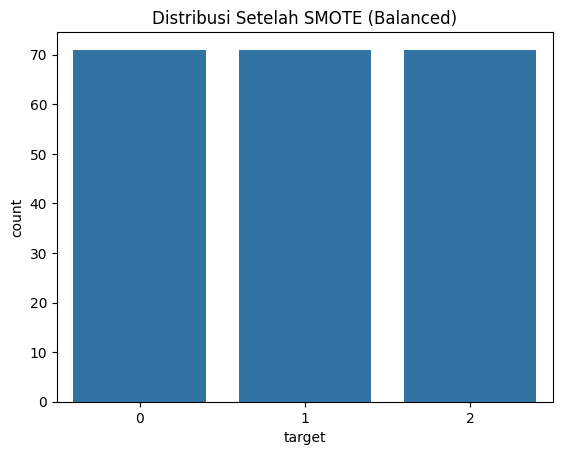

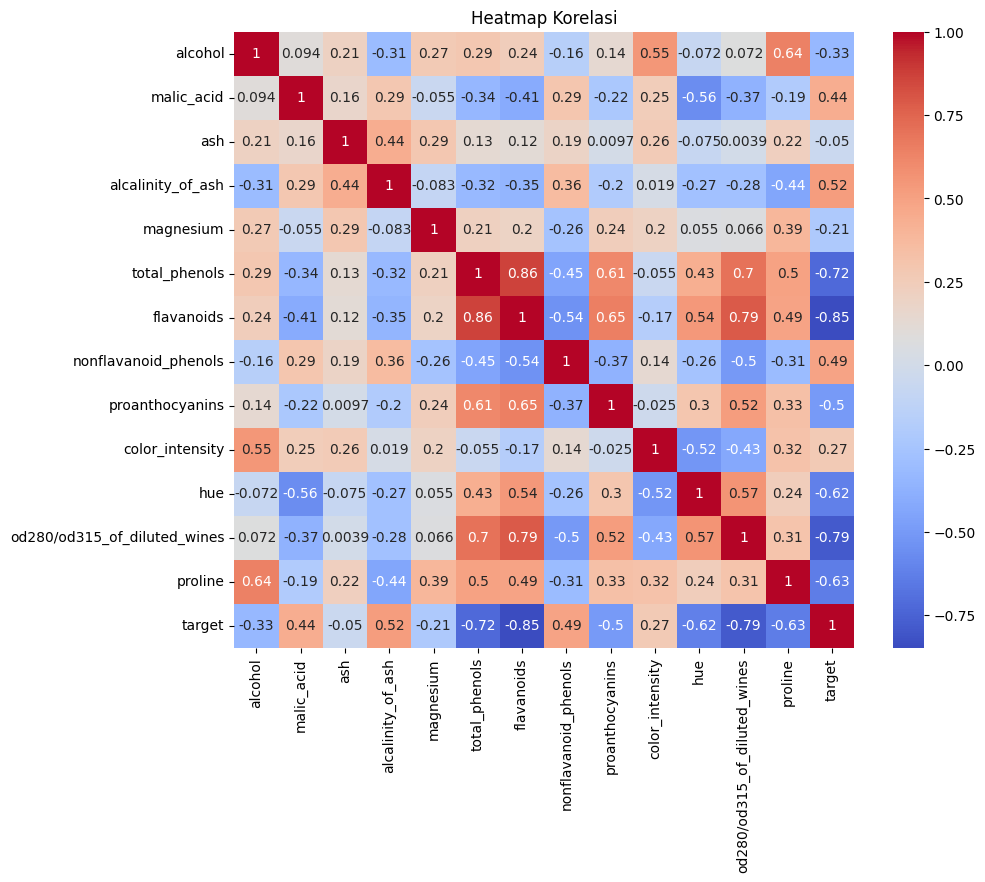

In [ ]:
# =========================================================
# 4. EDA
# =========================================================

# Distribusi target
sns.countplot(x=y_balanced)
plt.title("Distribusi Setelah SMOTE (Balanced)")
plt.show()

# Korelasi + angka
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.title("Heatmap Korelasi")
plt.show()

In [ ]:
# =========================================================
# 3. DATA PREPROCESSING
# =========================================================

# Cek missing value
print(df.isnull().sum())

# Split fitur dan target
X_train, X_test, y_train, y_test = train_test_split(
    X_balanced, y_balanced, test_size=test_size, random_state=42
)

# Scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# BALANCING DATA (SMOTE)
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_balanced, y_balanced = smote.fit_resample(X_scaled, y)

# Cek hasil balancing
print(pd.Series(y_balanced).value_counts())

alcohol                         0
malic_acid                      0
ash                             0
alcalinity_of_ash               0
magnesium                       0
total_phenols                   0
flavanoids                      0
nonflavanoid_phenols            0
proanthocyanins                 0
color_intensity                 0
hue                             0
od280/od315_of_diluted_wines    0
proline                         0
target                          0
dtype: int64
target
0    71
1    71
2    71
Name: count, dtype: int64


In [ ]:
# =========================================================
# 5. DATA SPLITTING
# =========================================================
splits = [
    (0.7, 0.3),
    (0.8, 0.2),
    (0.9, 0.1)
]

In [ ]:
# =========================================================
# 6. FUNCTION EVALUASI
# =========================================================
def evaluate_model(y_test, y_pred, model_name):
    acc = accuracy_score(y_test, y_pred)
    print(f"\n=== {model_name} ===")
    print("Accuracy:", acc)
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))

    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d')
    plt.title(f"Confusion Matrix - {model_name}")
    plt.show()

    return acc


In [ ]:
# =========================================================
# 7. MODEL TRAINING + TUNING
# =========================================================
results = []

for train_size, test_size in splits:

    print(f"\n===== SPLIT {int(train_size*100)}:{int(test_size*100)} =====")

    X_train, X_test, y_train, y_test = train_test_split(
        X_scaled, y, test_size=test_size, random_state=42
    )

    # -----------------------------
    # Logistic Regression
    # -----------------------------
    lr = LogisticRegression(max_iter=1000)
    lr.fit(X_train, y_train)
    y_pred_lr = lr.predict(X_test)
    acc_lr = accuracy_score(y_test, y_pred_lr)

    results.append(["Logistic Regression", f"{train_size}:{test_size}", acc_lr])


    # -----------------------------
    # Decision Tree + Tuning
    # -----------------------------
    param_dt = {
        'max_depth': [3, 5, 10, None]
    }

    grid_dt = GridSearchCV(DecisionTreeClassifier(), param_dt, cv=5)
    grid_dt.fit(X_train, y_train)

    best_dt = grid_dt.best_estimator_
    y_pred_dt = best_dt.predict(X_test)
    acc_dt = accuracy_score(y_test, y_pred_dt)

    results.append(["Decision Tree", f"{train_size}:{test_size}", acc_dt])


    # -----------------------------
    # Random Forest + Tuning
    # -----------------------------
    param_rf = {
        'n_estimators': [100, 200],
        'max_depth': [5, 10, None]
    }

    grid_rf = GridSearchCV(RandomForestClassifier(), param_rf, cv=5)
    grid_rf.fit(X_train, y_train)

    best_rf = grid_rf.best_estimator_
    y_pred_rf = best_rf.predict(X_test)
    acc_rf = accuracy_score(y_test, y_pred_rf)

    results.append(["Random Forest", f"{train_size}:{test_size}", acc_rf])



===== SPLIT 70:30 =====

===== SPLIT 80:20 =====

===== SPLIT 90:10 =====


In [ ]:
# =========================================================
# 8. MODEL COMPARISON
# =========================================================
results_df = pd.DataFrame(results, columns=["Model", "Split", "Accuracy"])

print("\n===== HASIL PERBANDINGAN =====")
print(results_df)



===== HASIL PERBANDINGAN =====
                 Model    Split  Accuracy
0  Logistic Regression  0.7:0.3  0.981481
1        Decision Tree  0.7:0.3  0.944444
2        Random Forest  0.7:0.3  1.000000
3  Logistic Regression  0.8:0.2  1.000000
4        Decision Tree  0.8:0.2  0.944444
5        Random Forest  0.8:0.2  1.000000
6  Logistic Regression  0.9:0.1  1.000000
7        Decision Tree  0.9:0.1  0.888889
8        Random Forest  0.9:0.1  1.000000


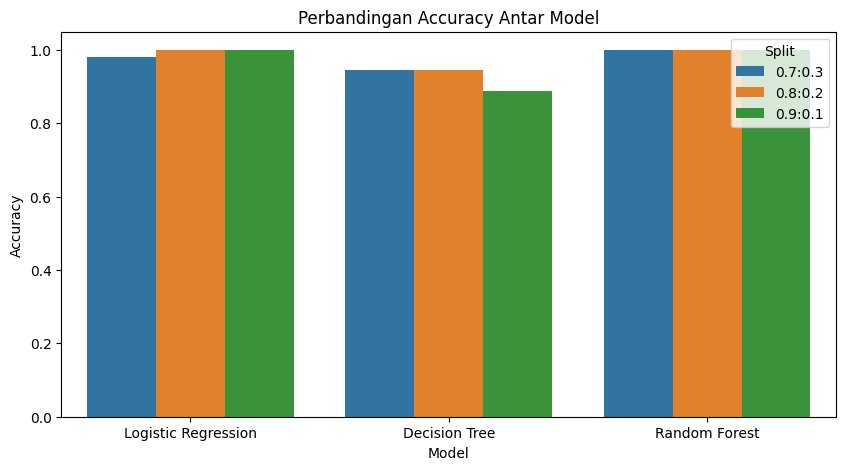

In [ ]:
# =========================================================
# 9. VISUALISASI
# =========================================================
plt.figure(figsize=(10,5))
sns.barplot(data=results_df, x="Model", y="Accuracy", hue="Split")
plt.title("Perbandingan Accuracy Antar Model")
plt.show()

In [ ]:
# =========================================================
# 10. MODEL TERBAIK
# =========================================================
best_model = results_df.sort_values(by="Accuracy", ascending=False).iloc[0]

print("\n===== MODEL TERBAIK =====")
print(best_model)


===== MODEL TERBAIK =====
Model       Random Forest
Split             0.7:0.3
Accuracy              1.0
Name: 2, dtype: object


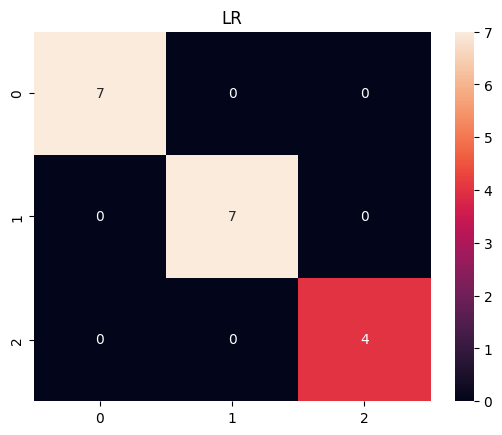

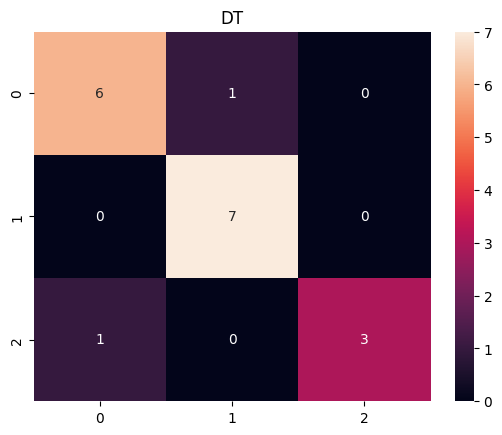

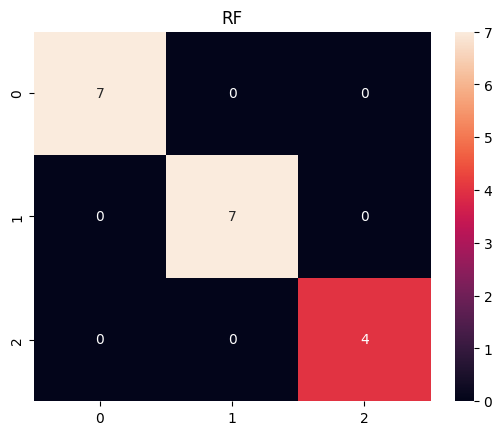

In [ ]:
# =========================================================
# 11. CONFUSION MATRIX
# =========================================================
def plot_cm(y_test, y_pred, title):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d')
    plt.title(title)
    plt.show()

plot_cm(y_test, y_pred_lr, "LR")
plot_cm(y_test, y_pred_dt, "DT")
plot_cm(y_test, y_pred_rf, "RF")